# Earthquake window -- all plots (v1)

Workflow:
1. **Read** the folder (only read, nothing else).
2. **Overview** of every sensor (downsampled) with the chosen time window marked
   in red -- use it to locate the earthquake and tune the window.
3. Pick **one device** (by introspection) and take that window.
4. See its **accelerogram in g**, then **Fourier**, **response spectrum** and more
   on that window. Every plot exposes its inputs (figsize, xlim, ylim, save).

Units: the package works in SI (m/s^2). For display in g pass ``factor=1/9.81``.
The overview reads the raw .h5 (already in g), so there ``factor=1.0`` shows g.

## 0. Imports

In [1]:
%matplotlib inline

import numpy as np
from datetime import datetime

from asdea_sensors import SensorDataset
from asdea_sensors.config import settings

## 1. Read the data (only read, nothing else)

In [2]:
folder = r"C:\Users\ppala\Desktop\02_31MAY2026"

ds = SensorDataset(folder, verbose=True)   # prints the summary; reads no signal yet
ds.devices                                  # what we have

------------------------------------------------------------
SensorDataset
------------------------------------------------------------
path        : C:\Users\ppala\Desktop\02_31MAY2026
files       : 32
time span   : 2026-05-31 14:52:12  ->  2026-05-31 20:02:13
duration    : 18601.0 s
devices     : MNAT0031, MNAT0034, MOF00134, MOF00135, MOF00136
fs / dt     : 252.5885 Hz / 0.003959 s
------------------------------------------------------------
axes (per sensor):
  MNAT0031   -> (3, 1, 5)
  MNAT0034   -> (3, 1, 5)
  MOF00134   -> (0, 1, 2)
  MOF00135   -> (3, 1, 5)
  MOF00136   -> (3, 1, 5)
------------------------------------------------------------
on-disk size: 782.17 MB
RAM         : used 33.26 GB / avail 0.26 GB (99%)
------------------------------------------------------------


['MNAT0031', 'MNAT0034', 'MOF00134', 'MOF00135', 'MOF00136']

## 2. Overview of all sensors + choose the window

Edit `start_time` / `end_time` to bracket the earthquake. The red dashed lines
show where the window falls over the whole record. `titles` is an input (no
globals): the floor label of each sensor.

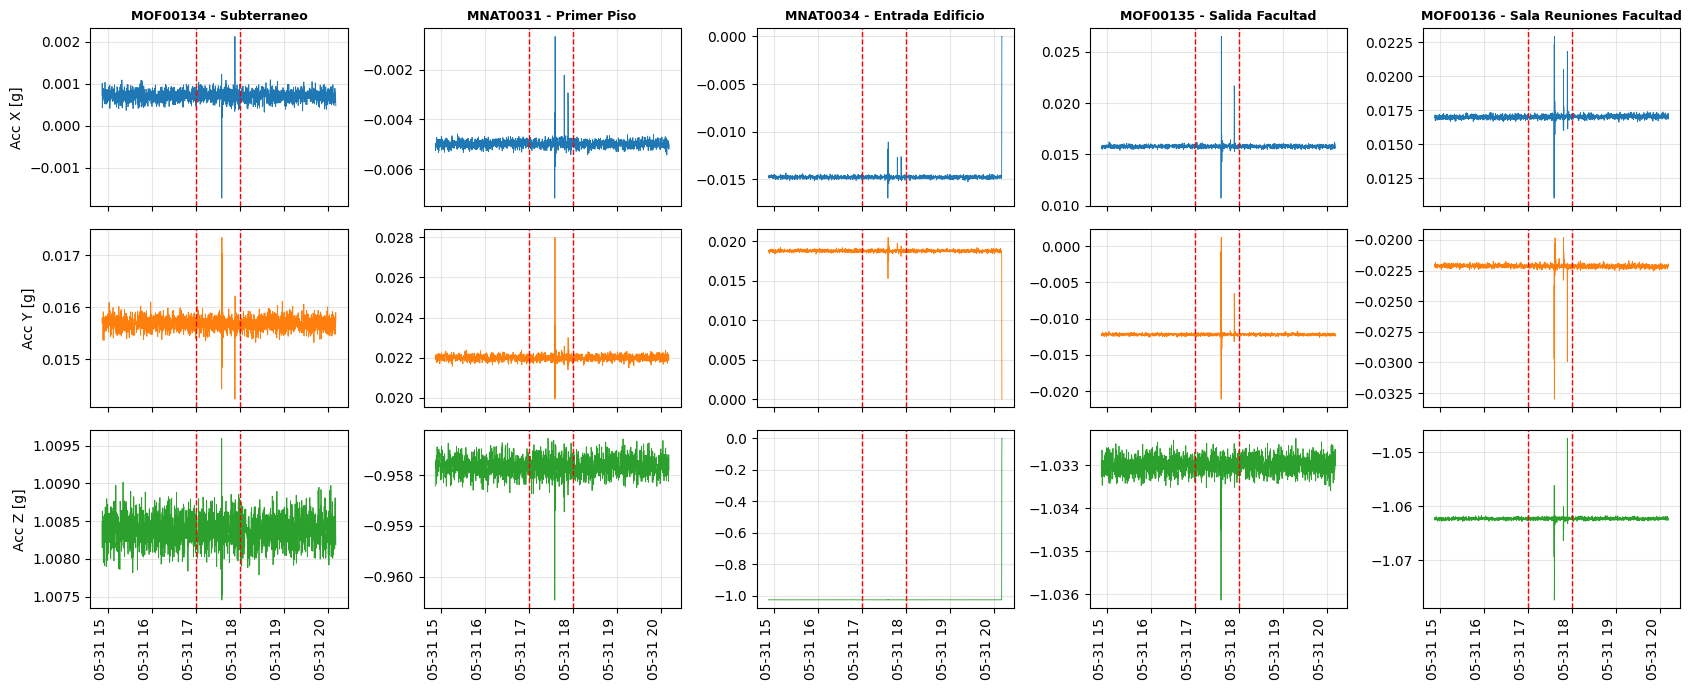

In [3]:
from asdea_sensors.plotting import overview_plots

# ---- inputs you tune ------------------------------------------------------
start_time = datetime(2026, 5, 31, 17, 0, 0)    # window start  (yyyy, m, d, H, M, S)
end_time   = datetime(2026, 5, 31, 18, 0, 0)    # window end

titles = {
    "MOF00134": "Subterraneo",
    "MNAT0031": "Primer Piso",
    "MNAT0034": "Entrada Edificio",
    "MOF00135": "Salida Facultad",
    "MOF00136": "Sala Reuniones Facultad",
}
# ---------------------------------------------------------------------------

overview_plots.plot_overview(
    ds,
    devices=["MOF00134", "MNAT0031", "MNAT0034", "MOF00135", "MOF00136"],
    titles=titles,
    factor=1.0,                 # raw is in g; use 9.81 for m/s^2
    unit="g",
    number_max_points=2000,     # schematic downsample
    window=(start_time, end_time),
    figsize=(17, 7),
    # save="overview.pdf",      # uncomment to save (pdf / svg / png / path)
)

## 3. Introspection: pick ONE device and take the window

In [4]:
print("available devices:", ds.devices)

device = "MOF00135"                                  # <-- choose one
W   = ds.device(device).get_window(start_time, end_time)
sig = W.signal(components="all")                     # read only the window
print("%s : %d samples, %.1f s, dt=%.6f s" % (device, sig.n, sig.duration, sig.dt))

available devices: ['MNAT0031', 'MNAT0034', 'MOF00134', 'MOF00135', 'MOF00136']


C:\Dropbox\01. Brain\11. GitHub\ladruno_ASDEA_sensors\src\asdea_sensors\core\h5_reader.py:45: UserWarning: H5Reader: axes (3, 1, 5) for 'MOF00135' exceed the 3 available columns; falling back to (0, 1, 2)
  warnings.warn(


[signal] MOF00135 n=895400 dt=0.004021 comps=all
MOF00135 : 895400 samples, 3600.3 s, dt=0.004021 s


## 4. Accelerogram of that device (in g)

`plot_signals` with all its inputs. `factor=1/9.81` converts m/s^2 -> g.

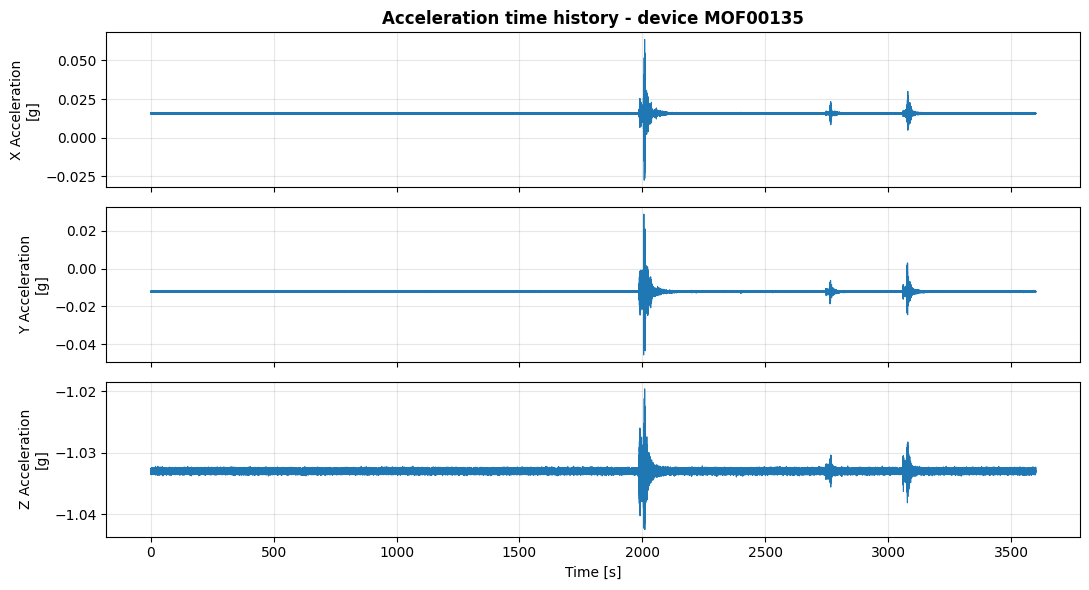

In [5]:
from asdea_sensors.plotting import signal_plots

signal_plots.plot_signals(
    sig,
    components="all",       # "x" | "y" | "z" | "all"
    kind="acc",             # "acc" | "vel" | "disp"
    factor=1/9.81,          # m/s^2 -> g
    unit="g",
    figsize=(11, 6),
    xlim=None,              # e.g. (0, 60) seconds
    ylim=None,              # e.g. (-0.02, 0.02) g
    # save="MOF00135_acc.pdf",
)

## 5. Process the window (baseline + band-pass)

Decoupled steps. These are inputs, not globals.

In [6]:
fmin, fmax = 0.1, 24.9            # band-pass edges [Hz]
WF  = W.baseline().filter(fmin, fmax, engine="scipy")
WFD = WF.derive()                 # velocity and displacement available

## 6. Fourier amplitude spectrum of the window

[fourier] MOF00135 comp=x nfreq=6 smooth=None (computed)


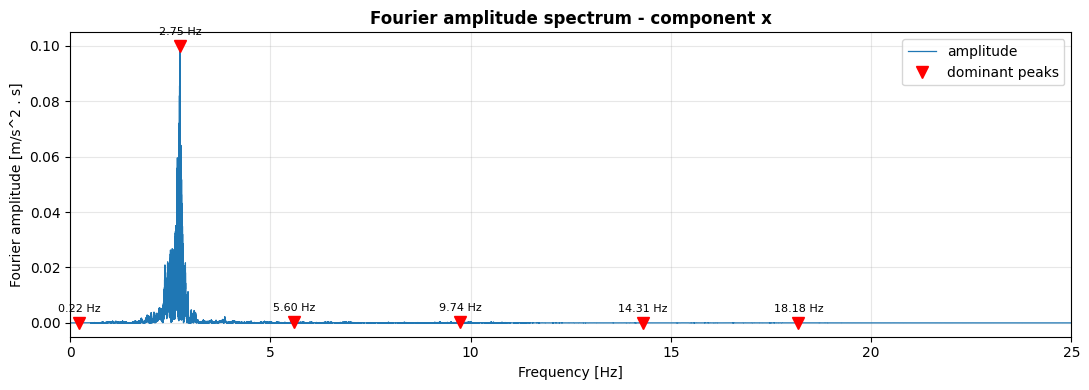

dominant freqs [Hz]: [2.75, 9.74, 5.6, 14.31, 18.18, 0.22]


In [7]:
from asdea_sensors.plotting import fourier_plots

fr = WF.fourier(
    component="x",
    num_frequencies=6,      # dominant peaks to mark
    prominence=1e-6,
    distance_frac=0.02,
    smooth=None,            # None or "konno"
    bexp=40,
)
fourier_plots.plot_fourier(
    fr, component="x", smooth=None,
    figsize=(11, 4), xlim=(0, 25), ylim=None,
    # save="MOF00135_fourier.pdf",
)
print("dominant freqs [Hz]:", [round(float(x), 2) for x in fr["dom_freqs"]])

## 7. Response spectrum (Newmark) in g

[newmark] MOF00135 comp=x zeta=0.05 Tmax=3.0 dT=0.02 -> 150 periods (computed)


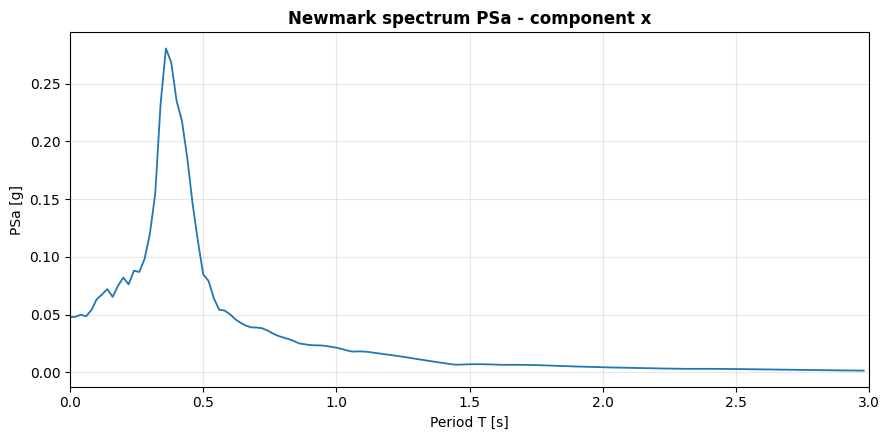

In [8]:
from asdea_sensors.plotting import newmark_plots

spec = WF.newmark(
    component="x",
    zeta=0.05,              # damping
    max_period=3.0,         # s
    dT=0.02,                # period step
    factor=1/9.81,          # PSa, Sa in g
)
newmark_plots.plot_newmark(
    spec, component="x", quantity="PSa", unit="g",
    figsize=(9, 4.5), xlim=(0, 3.0), ylim=None,
    # save="MOF00135_PSa.pdf",
)

## 8. PSD and spectrogram of the window

[psd] MOF00135 comp=x nperseg=512 (computed)


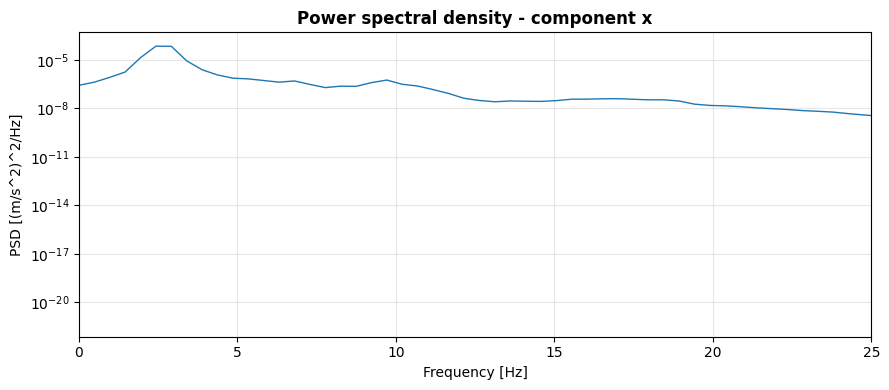

[stft] MOF00135 comp=x nperseg=256 fmax=25.0 (computed)


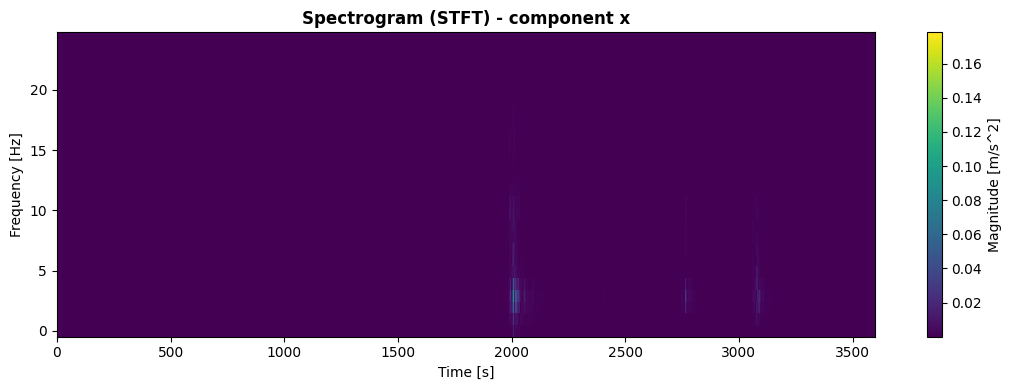

band energy: {'(0, 1)': 0.0, '(1, 2.5)': 2.5e-05, '(2.5, 5)': 2.4e-05, '(5, 10)': 2e-06}


In [9]:
from asdea_sensors.plotting import psd_plots, stft_plots

p = WF.psd(component="x", nperseg=512, noverlap=256,
           bands=[(0, 1), (1, 2.5), (2.5, 5), (5, 10)])
psd_plots.plot_psd(p, component="x", figsize=(9, 4), xlim=(0, 25),
                   # save="MOF00135_psd.pdf",
                   )

s = WF.stft(component="x", nperseg=256, noverlap=224, fmax=25.0)
stft_plots.plot_stft(s, component="x", figsize=(11, 4),
                     # save="MOF00135_stft.pdf",
                     )
print("band energy:", {str(k): round(float(v), 6) for k, v in p["band_energy"].items()})